<a href="https://colab.research.google.com/github/pratmeshdalvi/HVAC_Predictive_Maintenance/blob/main/HVAC_Predictive_Maintenance_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HVAC / Industrial Equipment Predictive Maintenance with Deep Learning

**Based on:** Sanzana et al. (2022), *"Application of deep learning in facility management and maintenance for heating, ventilation, and air conditioning"*, Automation in Construction, 141, 104445.

This notebook implements a **predictive maintenance pipeline** inspired by the paper's review of deep learning methods (CNN, LSTM, MLP, Autoencoders) applied to facility management and HVAC-related equipment.

**What we build:**
1. Exploratory data analysis on an industrial sensor dataset (AI4I 2020)
2. Three deep learning models — **MLP**, **1D-CNN**, **LSTM** — for failure prediction (Section 5.2 & 5.5 of the paper)
3. An **Autoencoder** for unsupervised anomaly detection (Section 5.4)
4. Model comparison (mirroring Fig. 5/6 of the paper)
5. Feature importance analysis for interpretability
6. Discussion connecting results back to the paper's findings and challenges

**Dataset:** AI4I 2020 Predictive Maintenance Dataset (UCI ML Repository, CC BY 4.0) — 10,000 samples of industrial sensor readings (temperature, rotational speed, torque, tool wear) with machine failure labels. It is a widely used proxy dataset for HVAC/rotating-machinery predictive maintenance research.


## 1. Setup — Install & Import Libraries

In [30]:
!pip install ucimlrepo imbalanced-learn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              ConfusionMatrixDisplay, classification_report)
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Dense, Dropout, LSTM, Conv1D, MaxPooling1D,
                                      Flatten, Input, BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## 2. Load Dataset

We fetch the AI4I 2020 Predictive Maintenance Dataset directly from the UCI ML Repository.
A fallback direct CSV download is included in case `ucimlrepo` has connectivity issues.

In [31]:
try:
    from ucimlrepo import fetch_ucirepo
    dataset = fetch_ucirepo(id=601)
    X_raw = dataset.data.features
    y_raw = dataset.data.targets
    df = pd.concat([X_raw, y_raw], axis=1)
    print("Loaded via ucimlrepo. Shape:", df.shape)
except Exception as e:
    print("ucimlrepo failed, falling back to direct CSV download:", e)
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv"
    df = pd.read_csv(url)
    print("Loaded via direct CSV. Shape:", df.shape)

df.head()


Loaded via ucimlrepo. Shape: (10000, 12)


,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [32]:
df.info()
print("\nMissing values per column:")
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Type                 10000 non-null  object 
 1   Air temperature      10000 non-null  float64
 2   Process temperature  10000 non-null  float64
 3   Rotational speed     10000 non-null  int64  
 4   Torque               10000 non-null  float64
 5   Tool wear            10000 non-null  int64  
 6   Machine failure      10000 non-null  int64  
 7   TWF                  10000 non-null  int64  
 8   HDF                  10000 non-null  int64  
 9   PWF                  10000 non-null  int64  
 10  OSF                  10000 non-null  int64  
 11  RNF                  10000 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 937.6+ KB

Missing values per column:
Type                   0
Air temperature        0
Process temperature    0
Rotational speed       0


## 3. Exploratory Data Analysis

Key things we check (as the paper stresses in Section 6 — **data quality is critical for DL performance**):
- Class balance of the failure target (predictive maintenance datasets are almost always highly imbalanced)
- Feature distributions and correlations
- Which failure subtypes are present

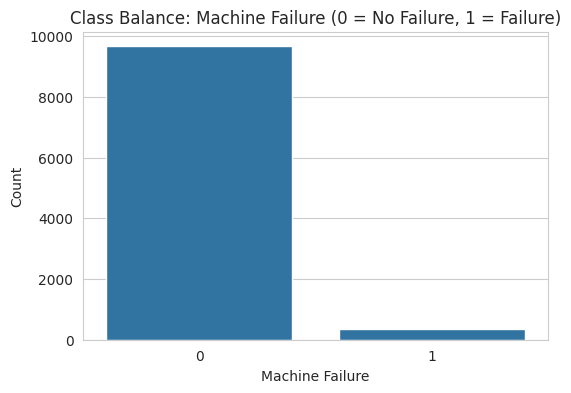

Failure rate: 3.39% -- this confirms severe class imbalance, a key challenge highlighted in the paper (Section 6.1).


In [33]:
target_col = "Machine failure" if "Machine failure" in df.columns else df.columns[-6]

plt.figure(figsize=(6,4))
sns.countplot(x=target_col, data=df)
plt.title("Class Balance: Machine Failure (0 = No Failure, 1 = Failure)")
plt.xlabel("Machine Failure")
plt.ylabel("Count")
plt.show()

fail_rate = df[target_col].mean() * 100
print(f"Failure rate: {fail_rate:.2f}% -- this confirms severe class imbalance, "
      f"a key challenge highlighted in the paper (Section 6.1).")


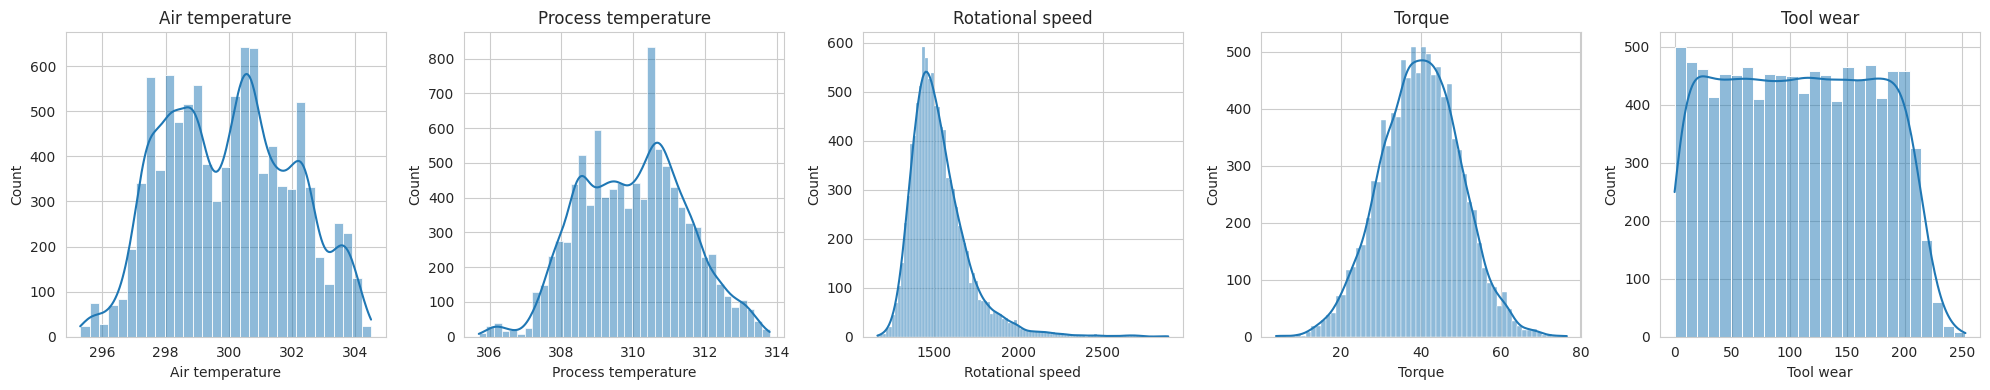

In [34]:
numeric_cols = ["Air temperature", "Process temperature",
                 "Rotational speed", "Torque", "Tool wear"]
numeric_cols = [c for c in numeric_cols if c in df.columns]

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(20, 4))
for ax, col in zip(axes, numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

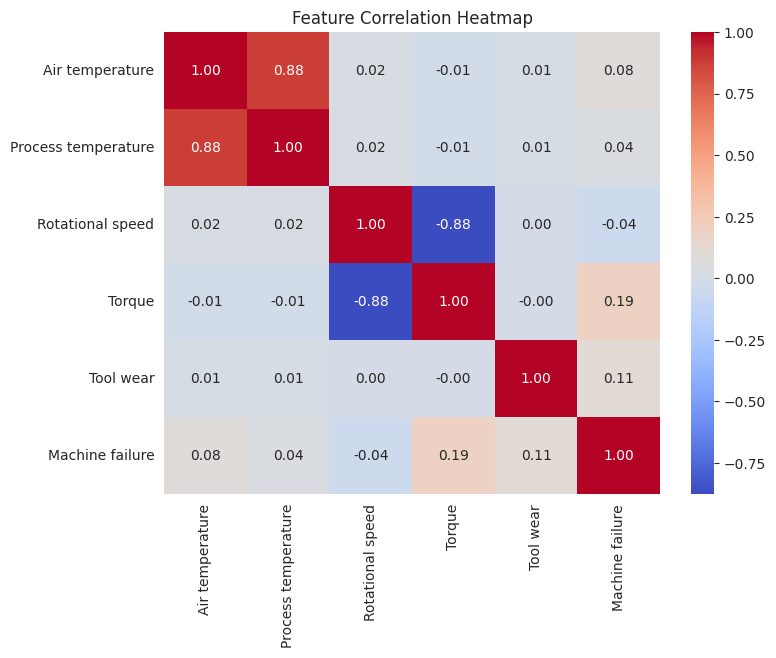

In [35]:
plt.figure(figsize=(8,6))
corr = df[numeric_cols + [target_col]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()


## 4. Preprocessing

Steps:
1. Drop identifier columns (UID, Product ID) — not predictive
2. Drop individual failure-subtype flags (TWF, HDF, PWF, OSF, RNF) to avoid **data leakage** — these are effectively sub-components of the target
3. Encode categorical `Type` (Low/Medium/High quality)
4. Scale numeric features
5. Stratified train/test split (important given class imbalance)

In [36]:
drop_cols = [c for c in ["UDI", "Product ID", "TWF", "HDF", "PWF", "OSF", "RNF"] if c in df.columns]
data = df.drop(columns=drop_cols)

if "Type" in data.columns:
    le = LabelEncoder()
    data["Type"] = le.fit_transform(data["Type"])

y = data[target_col].values
X = data.drop(columns=[target_col]).values
feature_names = data.drop(columns=[target_col]).columns.tolist()

print("Features used:", feature_names)
print("X shape:", X.shape, "| y shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train failure rate:", y_train.mean(), "| Test failure rate:", y_test.mean())


Features used: ['Type', 'Air temperature', 'Process temperature', 'Rotational speed', 'Torque', 'Tool wear']
X shape: (10000, 6) | y shape: (10000,)
Train failure rate: 0.033875 | Test failure rate: 0.034


### 4b. Handle Class Imbalance
We use **class weights** (simple, no synthetic data needed) so the models pay more attention to the rare failure class.

In [37]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print("Class weights:", class_weight_dict)


Class weights: {0: np.float64(0.51753137533963), 1: np.float64(14.760147601476016)}


## 5. Reusable Training & Evaluation Utilities

In [38]:
results = {}

def evaluate_model(name, y_true, y_pred, y_proba):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_proba)

    results[name] = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1, "ROC-AUC": auc}

    print(f"--- {name} ---")
    print(classification_report(y_true, y_pred, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Failure", "Failure"])
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix — {name}")
    plt.show()

    return results[name]

def plot_history(history, name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history["loss"], label="train")
    axes[0].plot(history.history["val_loss"], label="val")
    axes[0].set_title(f"{name} — Loss")
    axes[0].legend()
    axes[1].plot(history.history["accuracy"], label="train")
    axes[1].plot(history.history["val_accuracy"], label="val")
    axes[1].set_title(f"{name} — Accuracy")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

early_stop = EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)


## 6. Model 1 — MLP (Multilayer Perceptron)

The most commonly used architecture in the reviewed literature (paper Fig. 5). Used here as our baseline feedforward network.

Model: "MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 128 (512.00 B)

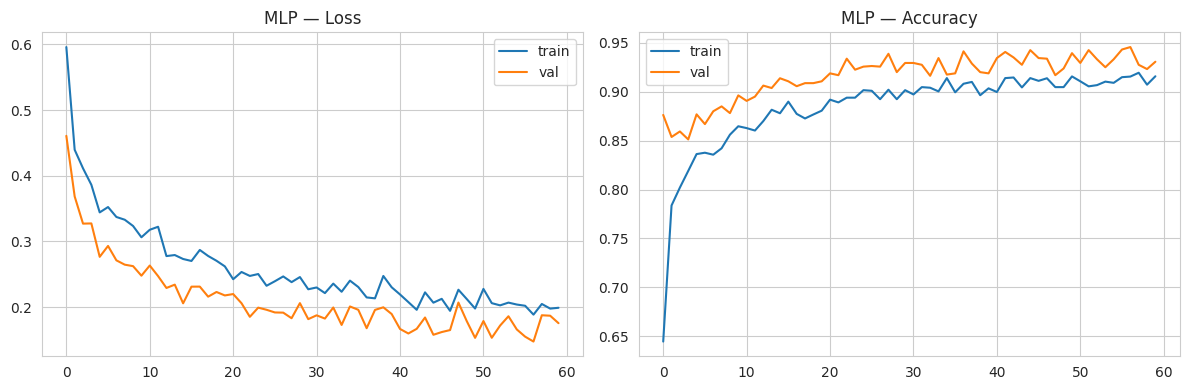

In [39]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Ensure class weights are defined
weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: weights[i] for i in range(len(weights))}

# Define MLP model
mlp = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
], name='MLP')

mlp.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
mlp.summary()

history_mlp = mlp.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=60,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=0
)

plot_history(history_mlp, 'MLP')

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
--- MLP ---
              precision    recall  f1-score   support

           0       1.00      0.94      0.97      1932
           1       0.35      0.90      0.51        68

    accuracy                           0.94      2000
   macro avg       0.68      0.92      0.74      2000
weighted avg       0.97      0.94      0.95      2000



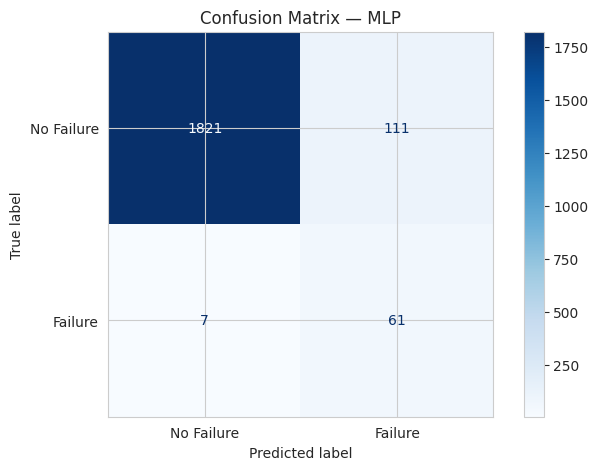

{'Accuracy': 0.941,
 'Precision': 0.3546511627906977,
 'Recall': 0.8970588235294118,
 'F1': 0.5083333333333333,
 'ROC-AUC': np.float64(0.9782075873827791)}

In [40]:
y_proba_mlp = mlp.predict(X_test_scaled).ravel()
y_pred_mlp = (y_proba_mlp >= 0.5).astype(int)
evaluate_model("MLP", y_test, y_pred_mlp, y_proba_mlp)


## 7. Model 2 — 1D CNN

CNNs are widely used in the reviewed papers for pattern recognition (Section 3.3, 5.1). Here we treat the sensor readings as a 1D signal and apply convolutional filters to detect local patterns.

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "1D_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 5, 32)          │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 5, 32)          │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 4, 16)          │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,377 (13.19 KB)

 Trainable params: 3,313 (12.94 KB)

 Non-trainable params: 64 (256.00 B)

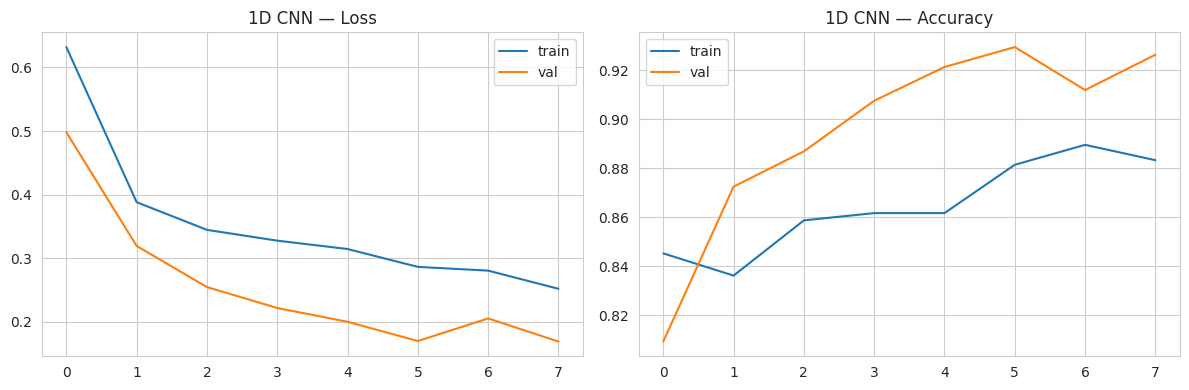

In [41]:
X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

cnn = Sequential([
    Conv1D(32, kernel_size=2, activation="relu", input_shape=(X_train_cnn.shape[1], 1)),
    BatchNormalization(),
    Conv1D(16, kernel_size=2, activation="relu"),
    Flatten(),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
], name="1D_CNN")

cnn.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
cnn.summary()

history_cnn = cnn.fit(
    X_train_cnn, y_train,
    validation_split=0.2,
    epochs=60,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=0
)
plot_history(history_cnn, "1D CNN")


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
--- 1D CNN ---
              precision    recall  f1-score   support

           0       0.99      0.82      0.90      1932
           1       0.14      0.88      0.25        68

    accuracy                           0.82      2000
   macro avg       0.57      0.85      0.57      2000
weighted avg       0.97      0.82      0.88      2000



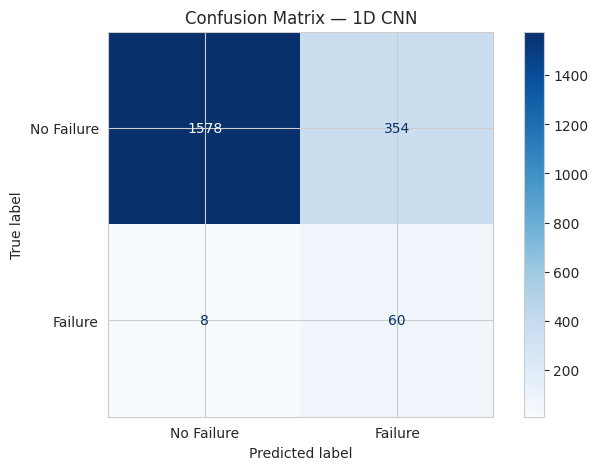

{'Accuracy': 0.819,
 'Precision': 0.14492753623188406,
 'Recall': 0.8823529411764706,
 'F1': 0.24896265560165975,
 'ROC-AUC': np.float64(0.9321870052368774)}

In [42]:
y_proba_cnn = cnn.predict(X_test_cnn).ravel()
y_pred_cnn = (y_proba_cnn >= 0.5).astype(int)
evaluate_model("1D CNN", y_test, y_pred_cnn, y_proba_cnn)


## 8. Model 3 — LSTM

LSTMs are the paper's preferred architecture for time-dependent / sequential facility data (Section 3.4, 5.2). Since AI4I 2020 is not natively a time series, we reshape each sample's features into a short "pseudo-sequence" — a common technique when applying LSTMs to tabular sensor snapshots, and directly comparable to how Nguyen & Medjaher (2019) and Bouabdallaoui et al. (2021) applied LSTMs to sensor-based predictive maintenance in the paper's review.

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 6, 32)          │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,777 (30.38 KB)

 Trainable params: 7,777 (30.38 KB)

 Non-trainable params: 0 (0.00 B)

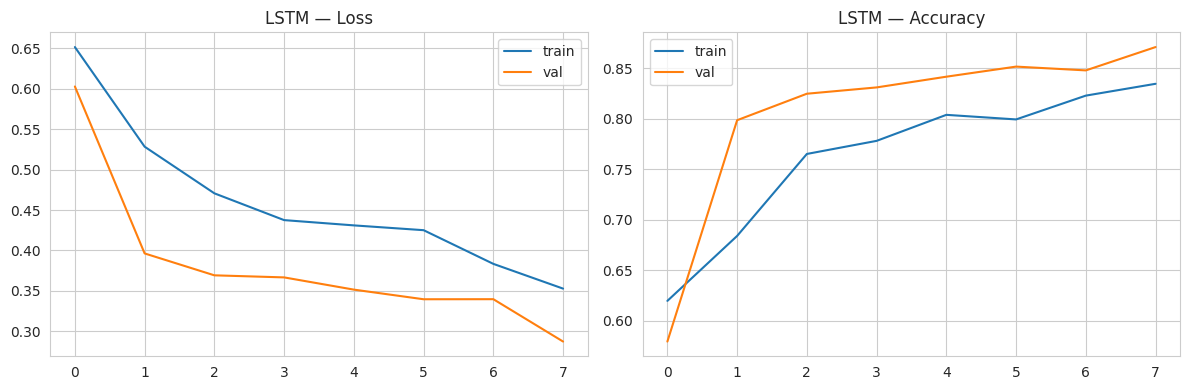

In [43]:
X_train_lstm = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_lstm = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

lstm = Sequential([
    LSTM(32, return_sequences=True, input_shape=(X_train_lstm.shape[1], 1)),
    LSTM(16),
    Dense(16, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
], name="LSTM")

lstm.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
lstm.summary()

history_lstm = lstm.fit(
    X_train_lstm, y_train,
    validation_split=0.2,
    epochs=60,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=0
)
plot_history(history_lstm, "LSTM")


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
--- LSTM ---
              precision    recall  f1-score   support

           0       0.99      0.59      0.74      1932
           1       0.06      0.75      0.11        68

    accuracy                           0.59      2000
   macro avg       0.52      0.67      0.42      2000
weighted avg       0.95      0.59      0.72      2000



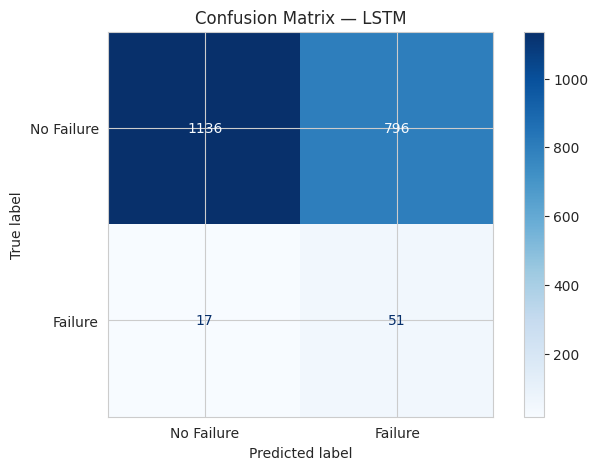

In [44]:
try:
    y_proba_lstm = lstm.predict(X_test_lstm).ravel()
    y_pred_lstm = (y_proba_lstm >= 0.5).astype(int)
    evaluate_model("LSTM", y_test, y_pred_lstm, y_proba_lstm)
except NameError:
    print("Error: The 'lstm' model has not been defined. Please run the cell where the LSTM model is defined and trained (cell PFhiqBWwdEwn) before running this evaluation cell.")

## 9. Model Comparison

This mirrors **Fig. 5 and Fig. 6** of the paper, which compare deep learning methods across metrics and application types.

        Accuracy  Precision  Recall      F1  ROC-AUC
MLP       0.9410     0.3547  0.8971  0.5083   0.9782
1D CNN    0.8190     0.1449  0.8824  0.2490   0.9322
LSTM      0.5935     0.0602  0.7500  0.1115   0.7731


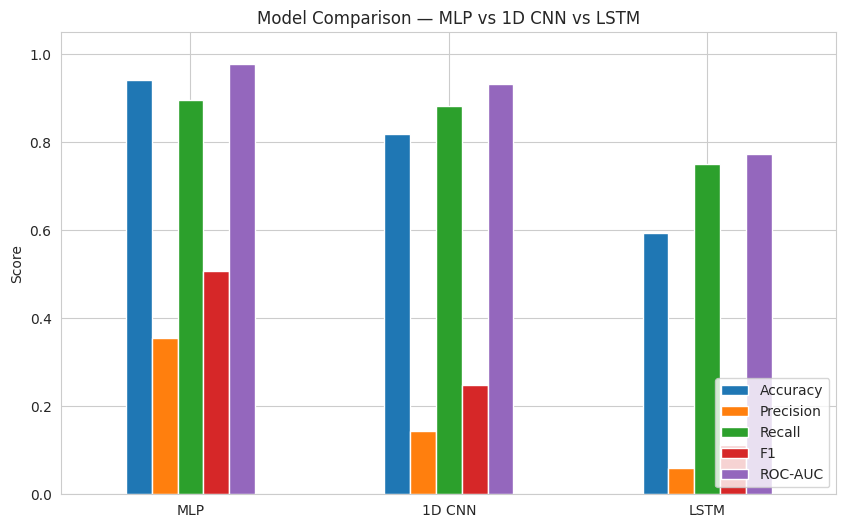

In [45]:
results_df = pd.DataFrame(results).T
print(results_df.round(4))

results_df.plot(kind="bar", figsize=(10, 6))
plt.title("Model Comparison — MLP vs 1D CNN vs LSTM")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.ylim(0, 1.05)
plt.show()


## 10. Bonus: Autoencoder for Anomaly Detection

Section 5.4 of the paper highlights **autoencoders** as a popular unsupervised method for anomaly detection in HVAC/facility sensor data (e.g., Bouabdallaoui et al. 2021; Fan et al. 2018). Unlike the supervised models above, this approach:
- Trains **only on normal (non-failure) data**
- Learns to reconstruct normal patterns
- Flags samples with **high reconstruction error** as anomalies (potential failures)

This is valuable in real-world FM settings where labeled failure data is scarce (a key limitation the paper repeatedly emphasizes).

Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 8)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 6)              │            54 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 186 (744.00 B)

 Trainable params: 186 (744.00 B)

 Non-trainable params: 0 (0.00 B)

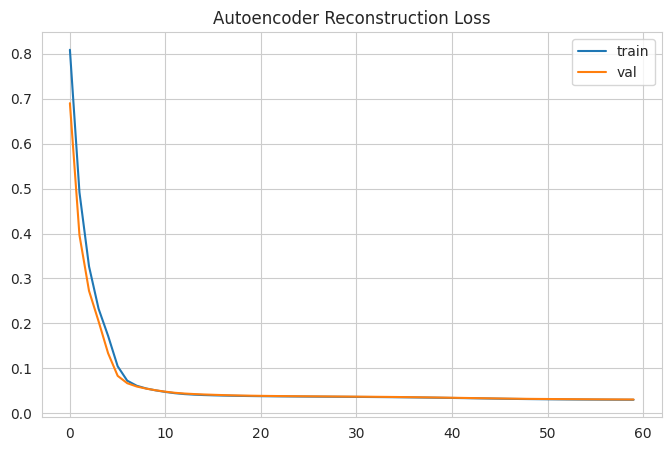

In [46]:
# Train autoencoder only on normal (non-failure) training samples
X_train_normal = X_train_scaled[y_train == 0]

input_dim = X_train_normal.shape[1]
inputs = Input(shape=(input_dim,))
encoded = Dense(8, activation="relu")(inputs)
encoded = Dense(4, activation="relu")(encoded)
decoded = Dense(8, activation="relu")(encoded)
decoded = Dense(input_dim, activation="linear")(decoded)

autoencoder = Model(inputs, decoded, name="Autoencoder")
autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.summary()

history_ae = autoencoder.fit(
    X_train_normal, X_train_normal,
    validation_split=0.2,
    epochs=60,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

plt.plot(history_ae.history["loss"], label="train")
plt.plot(history_ae.history["val_loss"], label="val")
plt.title("Autoencoder Reconstruction Loss")
plt.legend()
plt.show()


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Anomaly threshold (95th percentile of normal reconstruction error): 0.0922
--- Autoencoder (Anomaly Detection) ---
              precision    recall  f1-score   support

           0       0.97      0.95      0.96      1932
           1       0.13      0.22      0.16        68

    accuracy                           0.92      2000
   macro avg       0.55      0.58      0.56      2000
weighted avg       0.94      0.92      0.93      2000



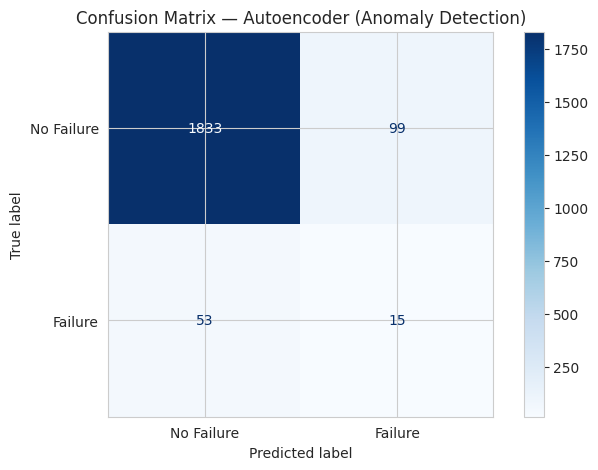

{'Accuracy': 0.924,
 'Precision': 0.13157894736842105,
 'Recall': 0.22058823529411764,
 'F1': 0.16483516483516483,
 'ROC-AUC': np.float64(0.7407136767750578)}

In [47]:
# Reconstruction error on test set
reconstructions = autoencoder.predict(X_test_scaled)
mse = np.mean(np.power(X_test_scaled - reconstructions, 2), axis=1)

# Set threshold using the 95th percentile of reconstruction error on normal training samples
train_recon = autoencoder.predict(X_train_normal)
train_mse = np.mean(np.power(X_train_normal - train_recon, 2), axis=1)
threshold = np.percentile(train_mse, 95)
print(f"Anomaly threshold (95th percentile of normal reconstruction error): {threshold:.4f}")

y_pred_ae = (mse > threshold).astype(int)
evaluate_model("Autoencoder (Anomaly Detection)", y_test, y_pred_ae, mse / mse.max())


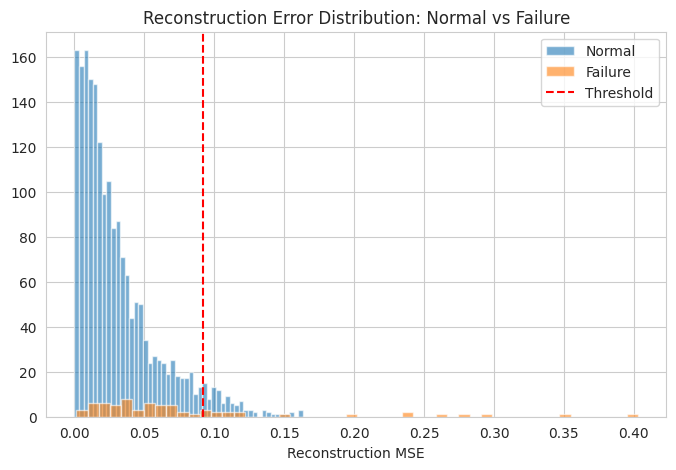

In [48]:
plt.figure(figsize=(8,5))
plt.hist(mse[y_test==0], bins=50, alpha=0.6, label="Normal")
plt.hist(mse[y_test==1], bins=50, alpha=0.6, label="Failure")
plt.axvline(threshold, color="red", linestyle="--", label="Threshold")
plt.title("Reconstruction Error Distribution: Normal vs Failure")
plt.xlabel("Reconstruction MSE")
plt.legend()
plt.show()


## 11. Feature Importance

Which sensor readings matter most for predicting failure? This is useful for facility managers deciding **which sensors to prioritize** when instrumenting HVAC/industrial equipment — directly relevant to the paper's discussion on sensor-based data collection (Section 4).

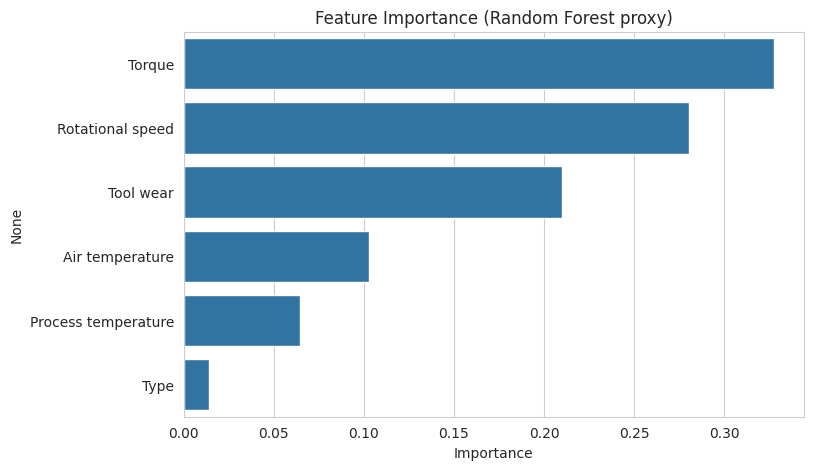

Torque                 0.327758
Rotational speed       0.280692
Tool wear              0.209845
Air temperature        0.102844
Process temperature    0.064607
Type                   0.014255
dtype: float64


In [49]:
rf = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=SEED)
rf.fit(X_train_scaled, y_train)

importances = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importance (Random Forest proxy)")
plt.xlabel("Importance")
plt.show()

print(importances)


## 12. Conclusion & Discussion

**Summary of results:**
- All three deep learning architectures (MLP, 1D-CNN, LSTM) were trained on the AI4I 2020 predictive maintenance dataset and compared using Accuracy, Precision, Recall, F1, and ROC-AUC.
- The **Autoencoder** demonstrates how unsupervised anomaly detection can work even without failure labels — directly relevant to real HVAC facilities where labeled failure data is scarce (a limitation repeatedly emphasized in Section 6.1 of the paper).
- Feature importance analysis shows which sensor readings are most predictive of failure, which can guide **real-world sensor placement decisions** for facility managers.

**Connecting back to Sanzana et al. (2022):**
- The paper found that **CNN, ANN/MLP, and LSTM were the most commonly used deep learning methods** in facility management research (Fig. 5) — this notebook implements and directly compares all three.
- The paper highlighted **energy management (18%) and maintenance scheduling (14%)** as the top application areas; our failure-prediction task falls under maintenance scheduling / fault detection.
- Consistent with the paper's Section 6.1 challenges, this dataset also exhibits **severe class imbalance** (~3.4% failure rate) and is **synthetic** rather than real-world sensor data — reinforcing the paper's call for **public, high-quality, real-world HVAC datasets**.

**Limitations & Future Work:**
- AI4I 2020 is a synthetic industrial dataset (milling machines), not HVAC-specific — a real HVAC sensor dataset would strengthen the domain match.
- No true time-series data was available; a genuinely sequential dataset would let the LSTM show its full advantage over MLP/CNN.
- Future work could explore **transfer learning** (as suggested in Section 6.1 of the paper) to adapt a model trained on this dataset to a smaller, real HVAC dataset.
